In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from torch_geometric.data import Data
import torch
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

Parse SMILES into molecular graphs

In [3]:
df_hetero = pd.read_csv('mol_datasets/s_hetero.csv')
df_hetero = df_hetero.drop(columns=["Unnamed: 0"])
df_hetero['label'] = 1
print(len(df_hetero))
df_hetero.head()

139


,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N,label
0,S1C=2C=CC=3C=CC=CC3C2C=4SC=5C=CC=6C=CC=CC6C5C14,0.21,0.20,6.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0,1
1,S1C=C2C=C3SC4=CC=CC=C4C3=CC2=C1,0.22,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1
2,S1C=CC=2C=C3C=C4C=CSC4=CC3=CC12,0.21,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1
3,S1C=CC=2C=C3SC=4C=C5C(SC=6C=C7C(SC=8C=C9C=CSC9...,0.18,0.08,9.0,8.0,0.0,0.0,5.0,0.0,0.0,0.0,1
4,S1C=C2C=C3C=C4SC=CC4=CC3=CC2=C1,0.17,0.08,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1


In [4]:
df_acenes = pd.read_csv('mol_datasets/acenes.csv')
df_acenes = df_acenes.drop(columns=["Unnamed: 0"])
df_acenes['label'] = 0
print(len(df_acenes))
df_acenes.head()

45


,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N,label
0,c1ccc2c(c1)ccc1ccccc12,0.316194,0.218750,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,c1ccc2cc3cc4c(ccc5cc6cc7ccccc7cc6cc54)cc3cc2c1,0.148908,0.065630,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,c1ccc2cc3c(ccc4c3ccc3c5cc6ccccc6cc5ccc34)cc2c1,0.125509,0.129530,7.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,c1ccc2c(c1)ccc1cc3c4ccccc4c4ccccc4c3cc12,0.180891,0.153495,6.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0
4,c1ccc2ccccc2c1,0.260865,0.186561,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [5]:
df = pd.concat([df_hetero, df_acenes])
df.head()

,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N,label
0,S1C=2C=CC=3C=CC=CC3C2C=4SC=5C=CC=6C=CC=CC6C5C14,0.21,0.20,6.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0,1
1,S1C=C2C=C3SC4=CC=CC=C4C3=CC2=C1,0.22,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1
2,S1C=CC=2C=C3C=C4C=CSC4=CC3=CC12,0.21,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1
3,S1C=CC=2C=C3SC=4C=C5C(SC=6C=C7C(SC=8C=C9C=CSC9...,0.18,0.08,9.0,8.0,0.0,0.0,5.0,0.0,0.0,0.0,1
4,S1C=C2C=C3C=C4SC=CC4=CC3=CC2=C1,0.17,0.08,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1


32


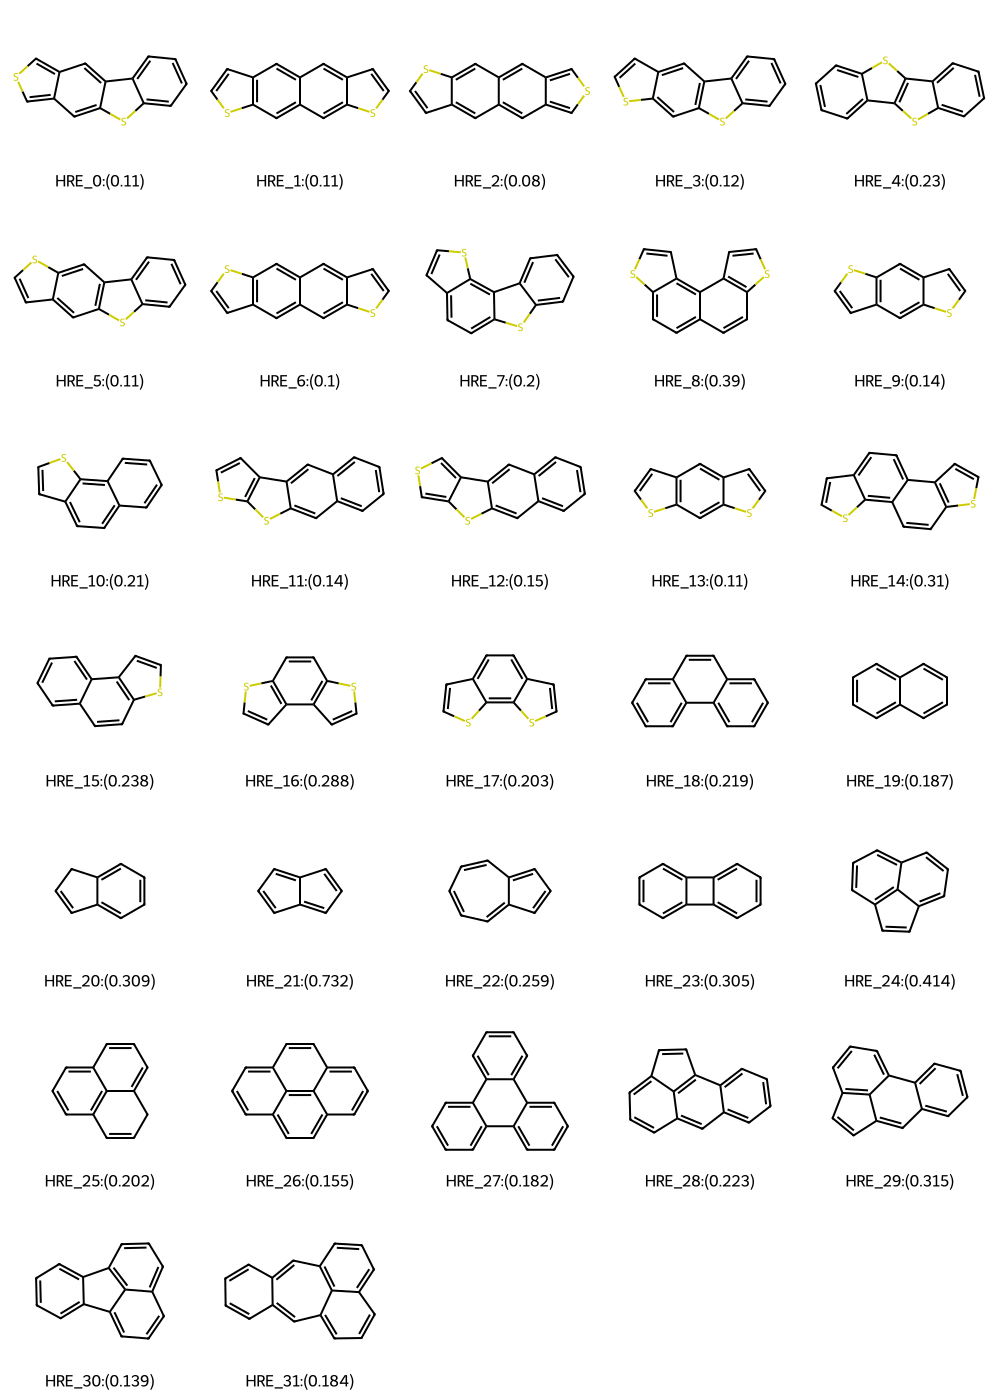

In [6]:
df_4_rings = df[df['rings']<4.1]
print(len(df_4_rings))
smiles_list = list(df_4_rings['SMILES'].values)
hres = list(df_4_rings['HRE'].values)
mols = [Chem.MolFromSmiles(s) for s in smiles_list]
hre_list = [round(i,3) for i in hres]
label_list = list(df['label'].values)
labels = [f"HRE_{i}:({hre_list[i]})" for i in range(len(df_4_rings))]
img = Draw.MolsToGridImage(mols[:], molsPerRow=5, subImgSize=(200,200), legends=labels)
img

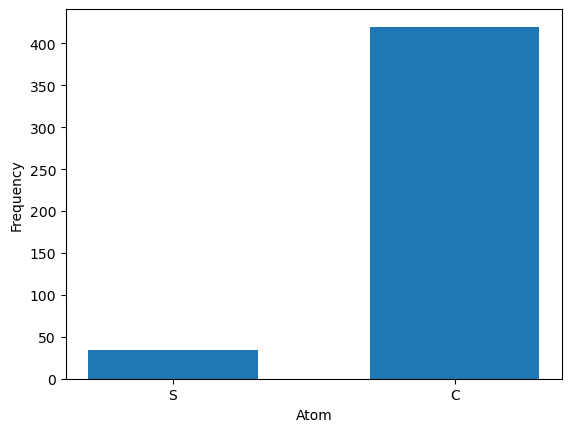

In [7]:
from collections import Counter
all_atoms = []
for smi in df_4_rings['SMILES'].values:
    mol = Chem.MolFromSmiles(smi)
    if mol:  
        for atom in mol.GetAtoms():
            all_atoms.append(atom.GetSymbol())

counts = Counter(all_atoms)
labels = list(counts.keys())
values = list(counts.values())
plt.bar(labels, values, align='center', width=0.6)
plt.xlabel("Atom")
plt.ylabel("Frequency")
plt.show()

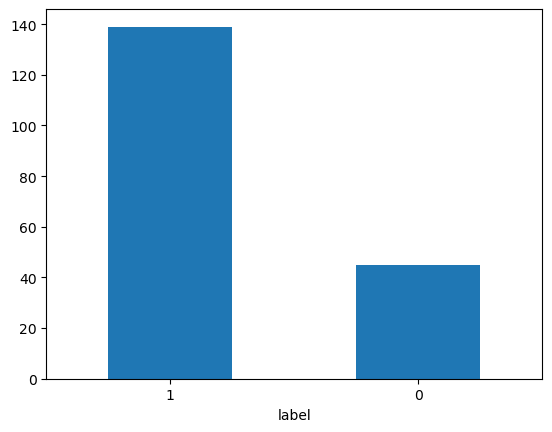

In [8]:
df['label'].value_counts().plot(kind='bar')
plt.xticks(rotation=0) 
plt.grid(False)
plt.show()

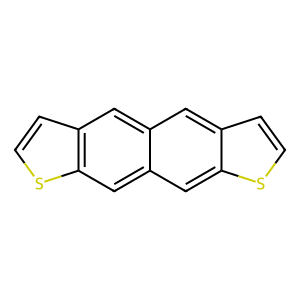

In [9]:
# Example usage
smiles = list(df_4_rings['SMILES'].values)[1]
hre = list(df_4_rings['HRE'].values)[1]

mol = Chem.MolFromSmiles(smiles)
img = Draw.MolsToGridImage([mol], molsPerRow=1, subImgSize=(300,300))
img

Data transformation : smiles to PyG data

In [10]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import torch
from torch_geometric.data import Data

# Example global mappings (adjust to your dataset)
NODE_MAPPING: dict[int, str] = {
    0: "C",
    1: "S",
    # add more atom types as needed
}

EDGE_MAPPING: dict[int, Chem.BondType] = {
    0: Chem.BondType.SINGLE,
    1: Chem.BondType.DOUBLE,
    2: Chem.BondType.TRIPLE,
    3: Chem.BondType.AROMATIC,
}

def atom_to_one_hot(atom: Chem.Atom, node_mapping: dict[int, str]) -> np.ndarray:
    """Convert an RDKit atom into a one-hot vector based on NODE_MAPPING."""
    num_classes = len(node_mapping)
    one_hot = np.zeros(num_classes, dtype=np.float32)
    for idx, symbol in node_mapping.items():
        if atom.GetSymbol() == symbol:
            one_hot[idx] = 1.0
            break
    return one_hot

def bond_to_one_hot(bond: Chem.Bond, edge_mapping: dict[int, Chem.BondType]) -> np.ndarray:
    """Convert an RDKit bond into a one-hot vector based on EDGE_MAPPING."""
    num_classes = len(edge_mapping)
    one_hot = np.zeros(num_classes, dtype=np.float32)
    for idx, btype in edge_mapping.items():
        if bond.GetBondType() == btype:
            one_hot[idx] = 1.0
            break
    return one_hot

def smiles_to_pyg(smiles_list: list[str], target_list: list[float] | None = None) -> list[Data]:
    """
    Convert a list of SMILES strings and optional target values into
    a list of PyTorch Geometric Data objects with one-hot node and edge features.
    """
    data_list = []
    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES string at index {i}: {smiles}")

        AllChem.Compute2DCoords(mol)

        # Node features: one-hot encoding
        x = np.array([atom_to_one_hot(atom, NODE_MAPPING) for atom in mol.GetAtoms()], dtype=np.float32)

        # Edge list and attributes: one-hot encoding
        edge_index, edge_attr = [], []
        for bond in mol.GetBonds():
            s, e = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edge_index += [[s, e], [e, s]]  # undirected
            edge_attr += [bond_to_one_hot(bond, EDGE_MAPPING)] * 2

        edge_index = np.array(edge_index, dtype=np.int64).T
        edge_attr = np.array(edge_attr, dtype=np.float32)

        # Target
        target = target_list[i] if target_list is not None else None
        y = np.array([target], dtype=np.float32) if target is not None else None

        # Positions (optional)
        # pos = np.array(mol.GetConformer().GetPositions()[..., :2], dtype=np.float32)

        # Wrap into PyG Data
        data = Data(
            x=torch.from_numpy(x),
            edge_index=torch.from_numpy(edge_index),
            edge_attr=torch.from_numpy(edge_attr),
            y=torch.from_numpy(np.round(y,5)) if y is not None else None,
            # pos=torch.from_numpy(pos),
        )
        data_list.append(data)

    return data_list

data = smiles_to_pyg(smiles_list, hre_list)

In [11]:
data[0]

Data(x=[16, 2], edge_index=[2, 38], edge_attr=[38, 4], y=[1])

In [12]:
import pulser as pl
from qek_main.qek.data.graphs import MoleculeGraphCompiler

compiler = MoleculeGraphCompiler()

In [14]:
from pathlib import Path
import qek_main.qek.data.extractors as qek_extractors

# Use the Qutip Extractor.
extractor = qek_extractors.QutipExtractor(
    # Once computing is complete, data will be saved in this file.
    path=Path("processed_data/test.json"),
    compiler=compiler
)

# Add the graphs using the compiler we've picked previously.
extractor.load_data(smiles_list=smiles_list, target_list=hre_list)

# We may now compile them
compiled = extractor.compile()
display("Compiled %s sequences" % (len(compiled), ))

/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, pr

'Compiled 32 sequences'

In [103]:
max_qubits = 16
processed_dataset = extractor.run(max_qubits=max_qubits).processed_data
display("Extracted features from %s samples"% (len(processed_dataset), ))

Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (18 > 16), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (18 > 16), skipping


/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:552: UserWarning: Register serialization to an abstract representation irreversibly converts all qubit ID's to strings.
  names = stringify_qubit_ids(self._ids)


processed data saved to processed_data/test.json


'Extracted features from 30 samples'

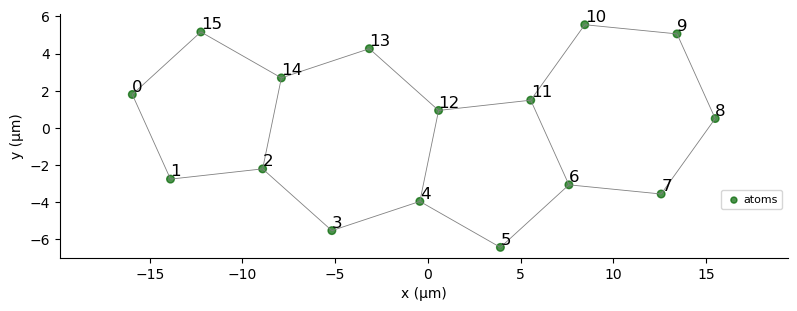

In [104]:
example = processed_dataset[0]
example.draw_register()

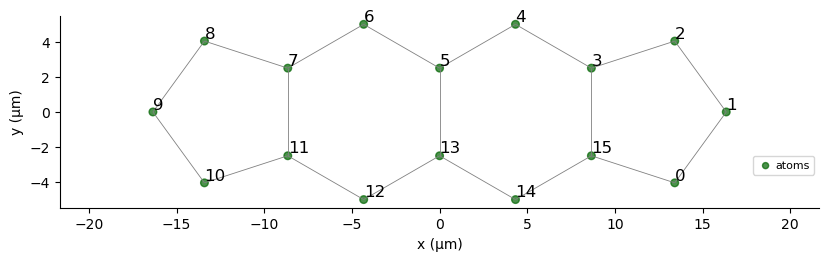

In [105]:
example = processed_dataset[1]
example.draw_register()

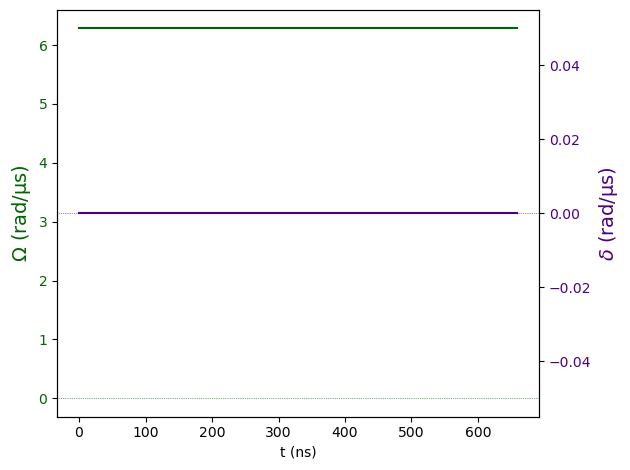

In [106]:
example.draw_pulse()

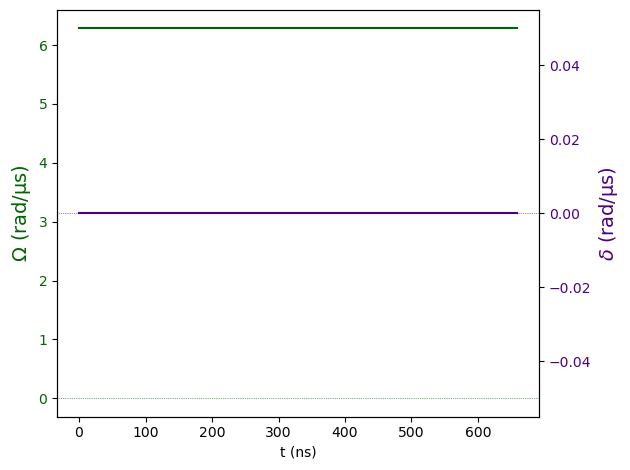

In [107]:
processed_dataset[1].draw_pulse() # same purses for all graphs?

In [108]:
display(example.state_dict)
print(f"Total number of samples: {sum(example.state_dict.values())}")

{'0000000101001001': 1,
 '0000000100001000': 10,
 '0000000000000001': 10,
 '0001001100010000': 1,
 '1010000000000010': 1,
 '0000000000000000': 127,
 '0000000000010101': 4,
 '0000100000000101': 10,
 '0000100010000001': 2,
 '0000000010001000': 3,
 '0010000000000001': 9,
 '0010000000000010': 3,
 '0000001000000000': 14,
 '0000100000000100': 12,
 '0000100000100000': 5,
 '1010110010010100': 1,
 '0100100000000010': 3,
 '0000000010000000': 10,
 '0000000000010001': 4,
 '0000000000101010': 3,
 '1010010000000000': 1,
 '0000000000001000': 18,
 '0000001000001001': 3,
 '0010010010100000': 1,
 '0000000010000001': 3,
 '0010000010100000': 1,
 '0010001010010010': 1,
 '0000100100100000': 2,
 '0001001000001000': 3,
 '1010000000001000': 1,
 '0000100000000000': 14,
 '0000001000001000': 12,
 '1010001000001000': 3,
 '0000000010010000': 12,
 '0000000000101000': 5,
 '0000000000000010': 9,
 '0001000000000010': 8,
 '0100100010010001': 1,
 '0000010000000000': 5,
 '0000100000000010': 8,
 '0000000100010000': 1,
 '00

Total number of samples: 1000


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


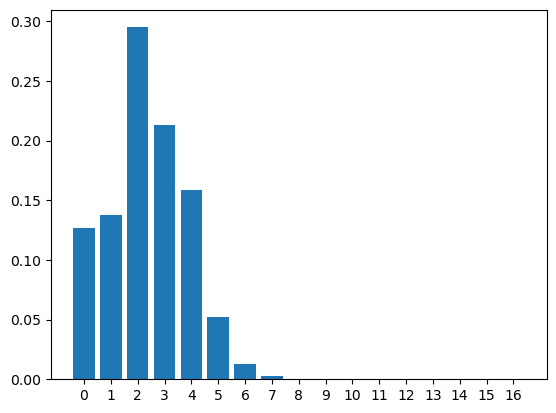

In [109]:
example.draw_excitation()

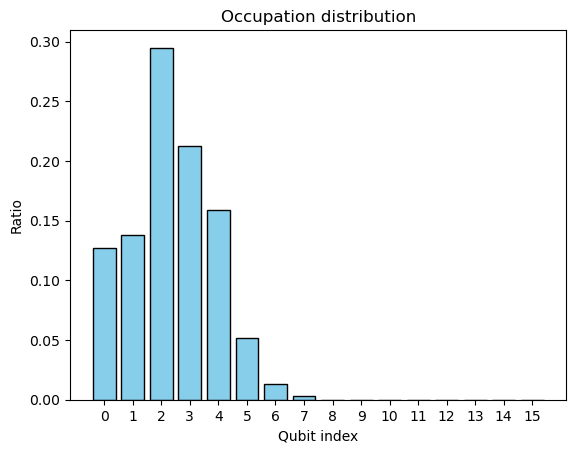

In [110]:
dist_excitation = np.zeros(max_qubits, dtype=int)

for state, weight in example.state_dict.items():
    num_up = state.count('1')
    dist_excitation[num_up] += weight

ratios = dist_excitation / dist_excitation.sum()

plt.bar(range(max_qubits), ratios, color="skyblue", edgecolor="black")
plt.xticks(range(16))
plt.xlabel("Qubit index")
plt.ylabel("Ratio")
plt.title('Occupation distribution')
plt.show()

In [111]:
from sklearn.model_selection import train_test_split
from qek.kernel import QuantumEvolutionKernel as QEK
from sklearn.svm import SVR, SVC
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

Kernel-based classification

In [117]:
y

[0.10999999940395355,
 0.10999999940395355,
 0.07999999821186066,
 0.11999999731779099,
 0.23000000417232513,
 0.10999999940395355,
 0.10000000149011612,
 0.20000000298023224,
 0.38999998569488525,
 0.14000000059604645,
 0.20999999344348907,
 0.14000000059604645,
 0.15000000596046448,
 0.10999999940395355,
 0.3100000023841858,
 0.23800000548362732,
 0.2879999876022339,
 0.2029999941587448,
 0.21899999678134918,
 0.18700000643730164,
 0.3089999854564667,
 0.7319999933242798,
 0.2590000033378601,
 0.3050000071525574,
 0.414000004529953,
 0.20200000703334808,
 0.1550000011920929,
 0.22300000488758087,
 0.3149999976158142,
 0.13899999856948853]

Kernel-based regression

In [123]:
X = [data for data in processed_dataset]  
y = [data.target for data in processed_dataset] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # remove stratify argument for regression

qek_kernel = QEK(mu=0.5)
model = SVR(kernel=qek_kernel)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.007930564049218674
MAE: 0.07245007077999331
R²: -0.2585922735023418


In [124]:
y

[0.10999999940395355,
 0.10999999940395355,
 0.07999999821186066,
 0.11999999731779099,
 0.23000000417232513,
 0.10999999940395355,
 0.10000000149011612,
 0.20000000298023224,
 0.38999998569488525,
 0.14000000059604645,
 0.20999999344348907,
 0.14000000059604645,
 0.15000000596046448,
 0.10999999940395355,
 0.3100000023841858,
 0.23800000548362732,
 0.2879999876022339,
 0.2029999941587448,
 0.21899999678134918,
 0.18700000643730164,
 0.3089999854564667,
 0.7319999933242798,
 0.2590000033378601,
 0.3050000071525574,
 0.414000004529953,
 0.20200000703334808,
 0.1550000011920929,
 0.22300000488758087,
 0.3149999976158142,
 0.13899999856948853]

In [125]:
qek_kernel = QEK(mu=0.5)
model = SVR(kernel=qek_kernel)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.007930564049218674
MAE: 0.07245007077999331
R²: -0.2585922735023418


In [126]:
from scipy.spatial.distance import jensenshannon

max_size = max(len(data.dist_excitation()) for data in processed_dataset)
distributions = [data.dist_excitation(size=max_size) for data in processed_dataset]
y = np.array([data.target for data in processed_dataset])

# Pairwise JSD distances
n = len(distributions)
distance_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = jensenshannon(distributions[i], distributions[j])

# Convert to similarity (kernel) matrix
similarity_matrix = 1 - distance_matrix

In [127]:
similarity_matrix.shape

(30, 30)

In [128]:
# Train/test split
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.4, random_state=42)

# Extract submatrices for training and testing
K_train = similarity_matrix[np.ix_(train_idx, train_idx)]
K_test = similarity_matrix[np.ix_(test_idx, train_idx)]

y_train, y_test = y[train_idx], y[test_idx]

# SVR with precomputed kernel
svr = SVR(kernel="precomputed")
svr.fit(K_train, y_train)
y_pred = svr.predict(K_test)

print("SVR with JSD kernel")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


SVR with JSD kernel
MSE: 0.008916437424510978
MAE: 0.07729615075972518
R²: -0.06603885183932112


In [129]:
from sklearn.manifold import MDS
from sklearn.ensemble import RandomForestRegressor

# Embed distance matrix into Euclidean space
embedding = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_embedded = embedding.fit_transform(distance_matrix)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_embedded, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest with JSD embedding")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest with JSD embedding
MSE: 0.008830333559962659
MAE: 0.07794999862710635
R²: -0.40138702897335166


/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
